In [ ]:
!pip install -q matplotlib scikit-learn pandas streamlit pyngrok joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 56.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
import joblib
import warnings
warnings.filterwarnings("ignore")


In [ ]:

from google.colab import files
import io

print("📂 Upload merged CSV file (with AQI):")
uploaded = files.upload()
csv_file = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[csv_file]))
print(f"✅ Uploaded: {csv_file}")
print(f"🔢 Shape: {df.shape}")
df.head()


📂 Upload merged CSV file (with AQI):


Saving combined_air_quality_data.csv to combined_air_quality_data.csv
✅ Uploaded: combined_air_quality_data.csv
🔢 Shape: (85652, 16)


,StationId,Date,PM25,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,100.0,10.76,109.26,0.17,5.92,0.10,184.0,Moderate
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,120.0,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,140.0,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,110.0,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,90.0,19.00,138.18,0.17,5.02,0.07,188.0,Moderate


In [ ]:
df = pd.read_csv('/content/combined_air_quality_data.csv')
display(df.head())

,StationId,Date,PM25,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,100.0,10.76,109.26,0.17,5.92,0.10,184.0,Moderate
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,120.0,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,140.0,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,110.0,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,90.0,19.00,138.18,0.17,5.02,0.07,188.0,Moderate


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import joblib

# Drop rows with missing values (if any)
df = df.dropna()

# Define features and target
# Drop non-numeric columns like 'StationId', 'Date', and 'AQI_Bucket' as they cannot be directly used by RandomForestRegressor
columns_to_drop = ['AQI', 'StationId', 'Date', 'AQI_Bucket']
# Ensure only existing columns are dropped to avoid errors
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
X = df.drop(columns=existing_columns_to_drop)
y = df['AQI']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# Save the trained model and feature names
joblib.dump(model, "best_model.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

print("✅ Random Forest model and features saved!")

✅ Random Forest model and features saved!


In [ ]:
from google.colab import files
files.download("best_model.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 60.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2


In [ ]:
# Drop irrelevant or all-null columns
df.dropna(axis=1, how='all', inplace=True)
df.drop(columns=[col for col in ['Date', 'date', 'Timestamp', 'timestamp', 'City', 'StationId', 'StationID', 'CityId','AQI_Bucket'] if col in df.columns], inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"🧹 Cleaned data shape: {df.shape}")


🧹 Cleaned data shape: (74615, 13)


🔎 Head:
     PM25    PM10    NO    NO2    NOx    NH3     CO    SO2      O3  Benzene  \
0  71.36  115.75  1.75  20.65  12.40  12.19  100.0  10.76  109.26     0.17   
1  81.40  124.50  1.44  20.50  12.08  10.72  120.0  15.24  127.09     0.20   
2  78.32  129.06  1.26  26.00  14.85  10.28  140.0  26.96  117.44     0.22   
3  88.76  135.32  6.60  30.85  21.77  12.91  110.0  33.59  111.81     0.29   
4  64.18  104.09  2.56  28.07  17.01  11.42   90.0  19.00  138.18     0.17   

   Toluene  Xylene    AQI  
0     5.92    0.10  184.0  
1     6.50    0.06  184.0  
2     7.95    0.08  197.0  
3     7.63    0.12  198.0  
4     5.02    0.07  188.0  

ℹ️ Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74615 entries, 0 to 74614
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PM25     74615 non-null  float64
 1   PM10     74615 non-null  float64
 2   NO       74615 non-null  float64
 3   NO2      74615 non-null  float64
 4   NO

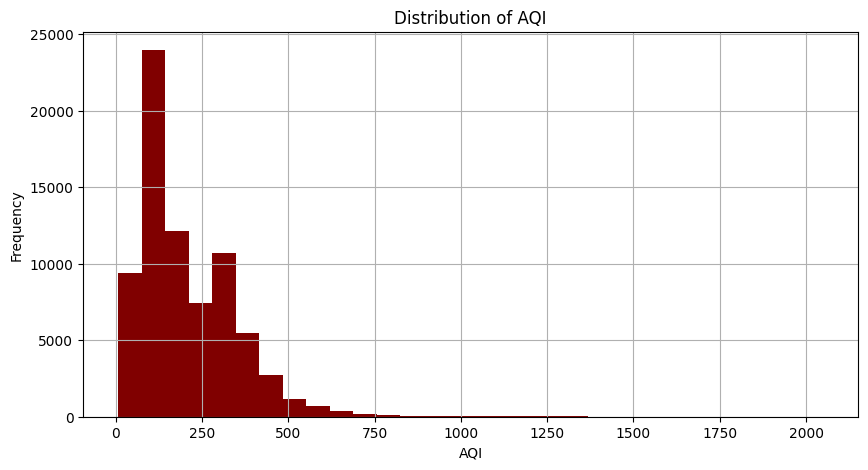

In [ ]:
print("🔎 Head:\n", df.head())
print("\nℹ️ Info:")
df.info()
print("\n❓ Nulls:\n", df.isna().sum())
print("\n🧩 Duplicates:\n", df.duplicated().sum())
print("\n📊 Describe:\n", df.describe())

if 'AQI' in df.columns:
    plt.figure(figsize=(10,5))
    plt.hist(df['AQI'], bins=30, color='#800000')
    plt.title("Distribution of AQI")
    plt.xlabel("AQI")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()
else:
    raise ValueError("⚠️ 'AQI' column not found!")



In [ ]:
target_col = 'AQI'
X = df.drop(columns=[target_col])
y = df[target_col]

# Label encode any categorical feature columns
for col in X.select_dtypes(include='object').columns:
   X[col] = LabelEncoder().fit_transform(X[col])
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"🧠 Features: {X.columns.tolist()}")
print(f"📊 Train shape: {xtrain.shape}, Test shape: {xtest.shape}")


🧠 Features: ['PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
📊 Train shape: (59692, 12), Test shape: (14923, 12)


In [ ]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostRegressor(n_estimators=50, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=50, random_state=42),
    'KNeighbors': KNeighborsRegressor(n_neighbors=5)
}
results = {'Model':[], 'Train_R2':[], 'Test_R2':[]}
for name, model in models.items():
    model.fit(xtrain, ytrain)
    train_r2 = r2_score(ytrain, model.predict(xtrain)) * 100
    test_r2 = r2_score(ytest, model.predict(xtest)) * 100
    results['Model'].append(name)
    results['Train_R2'].append(train_r2)
    results['Test_R2'].append(test_r2)
    print(f"{name} - Train R2: {train_r2:.2f}%, Test R2: {test_r2:.2f}%")

score_df = pd.DataFrame(results)
score_df

LinearRegression - Train R2: 76.92%, Test R2: 77.82%
DecisionTree - Train R2: 99.98%, Test R2: 86.97%
RandomForest - Train R2: 98.94%, Test R2: 92.61%
AdaBoost - Train R2: 25.64%, Test R2: 24.68%
GradientBoosting - Train R2: 87.04%, Test R2: 86.55%
KNeighbors - Train R2: 90.62%, Test R2: 85.58%


,Model,Train_R2,Test_R2
0,LinearRegression,76.918210,77.824581
1,DecisionTree,99.984185,86.968984
2,RandomForest,98.943080,92.613766
3,AdaBoost,25.637793,24.676970
4,GradientBoosting,87.040606,86.550381
5,KNeighbors,90.620228,85.575543


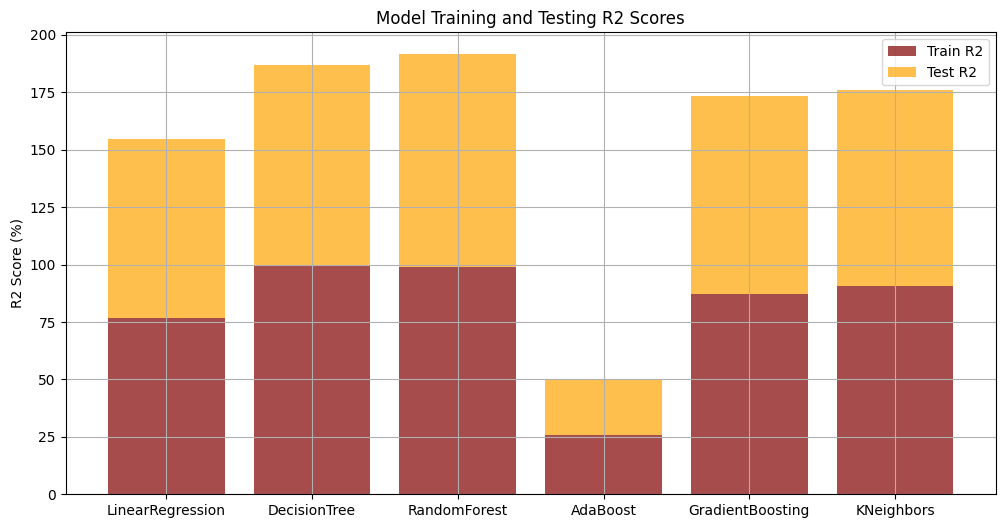

🏆 Best model based on Test R2: RandomForest


['feature_columns.pkl']

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(score_df['Model'], score_df['Train_R2'], color='maroon', alpha=0.7, label='Train R2')
plt.bar(score_df['Model'], score_df['Test_R2'], color='orange', alpha=0.7, label='Test R2', bottom=score_df['Train_R2'])
plt.ylabel('R2 Score (%)')
plt.title('Model Training and Testing R2 Scores')
plt.legend()
plt.grid(True)
plt.show()

best_model_name = score_df.loc[score_df['Test_R2'].idxmax(), 'Model']
print(f"🏆 Best model based on Test R2: {best_model_name}")

best_model = models[best_model_name]
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')


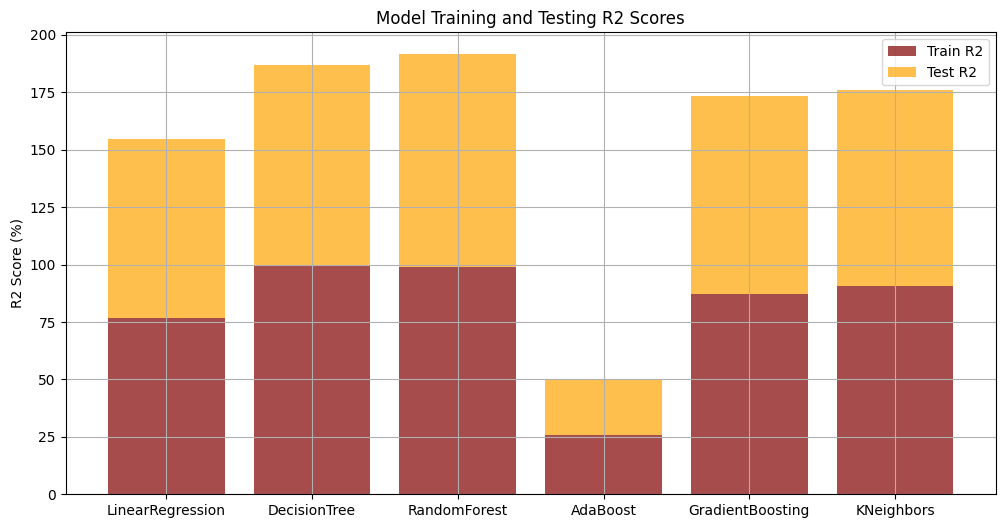

🏆 Best model based on Test R2: RandomForest


['feature_columns.pkl']

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(score_df['Model'], score_df['Train_R2'], color='maroon', alpha=0.7, label='Train R2')
plt.bar(score_df['Model'], score_df['Test_R2'], color='orange', alpha=0.7, label='Test R2', bottom=score_df['Train_R2'])
plt.ylabel('R2 Score (%)')
plt.title('Model Training and Testing R2 Scores')
plt.legend()
plt.grid(True)
plt.show()

best_model_name = score_df.loc[score_df['Test_R2'].idxmax(), 'Model']
print(f"🏆 Best model based on Test R2: {best_model_name}")

best_model = models[best_model_name]
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')


In [56]:

import streamlit as st
import pandas as pd
import joblib

# =========================
# PAGE CONFIG
# =========================
st.set_page_config(
    page_title="AQI Predictor",
    page_icon="🌍",
    layout="wide"
)

# =========================
# LOAD MODEL
# =========================
model = joblib.load("best_model.pkl")
feature_cols = joblib.load("feature_columns.pkl")

# =========================
# CUSTOM CSS
# =========================
st.markdown("""
<style>

.main {
    background-color: #0f172a;
    color: white;
}

h1, h2, h3 {
    color: white;
}

.stNumberInput label {
    color: white !important;
    font-weight: 600;
}

.stButton>button {
    width: 100%;
    background: linear-gradient(90deg,#00c6ff,#0072ff);
    color: white;
    font-size: 18px;
    font-weight: bold;
    border-radius: 12px;
    border: none;
    padding: 12px;
    transition: 0.3s;
}

.stButton>button:hover {
    transform: scale(1.02);
    background: linear-gradient(90deg,#0072ff,#00c6ff);
}

.metric-card {
    background-color: #1e293b;
    padding: 15px;
    border-radius: 15px;
    text-align: center;
    margin-bottom: 15px;
    box-shadow: 0px 4px 15px rgba(0,0,0,0.3);
}

.result-box {
    padding: 25px;
    border-radius: 15px;
    text-align: center;
    font-size: 26px;
    font-weight: bold;
    color: white;
    margin-top: 20px;
}

.small-text {
    color: #cbd5e1;
    font-size: 15px;
}

</style>
""", unsafe_allow_html=True)

# =========================
# HEADER
# =========================
st.markdown("""
# 🌍 Air Quality Index Predictor
### AQI Prediction using the Best Performing ML Model
""")

st.markdown(
    "<p class='small-text'>Built using Streamlit and Machine Learning model comparison analysis.</p>",
    unsafe_allow_html=True
)

# =========================
# SIDEBAR
# =========================
st.sidebar.title("📘 About")

st.sidebar.info("""
This project predicts AQI using Machine Learning.

Multiple regression models were compared during analysis, and the best-performing model was selected for deployment.

Models compared:
- Linear Regression
- Random Forest
- AdaBoost
- Gradient Boosting
- KNN
""")

st.sidebar.success("Developed by Aardra")

# =========================
# INPUT SECTION
# =========================
st.markdown("## 📥 Enter Pollutant Values")

cols = st.columns(2)

user_input = {}

for i, feature in enumerate(feature_cols):

    with cols[i % 2]:

        value = st.number_input(
            f"{feature}",
            min_value=0.0,
            value=5.0,
            step=0.1
        )

        user_input[feature] = value

# =========================
# PREDICTION
# =========================
input_df = pd.DataFrame([user_input])

if st.button("🚀 Predict AQI"):

    prediction = model.predict(input_df)[0]

    # AQI Classification
    if prediction <= 50:
        category = "🟢 Good"
        color = "#22c55e"

    elif prediction <= 100:
        category = "🟡 Moderate"
        color = "#eab308"

    elif prediction <= 150:
        category = "🟠 Unhealthy for Sensitive Groups"
        color = "#f97316"

    elif prediction <= 200:
        category = "🔴 Unhealthy"
        color = "#ef4444"

    elif prediction <= 300:
        category = "🟣 Very Unhealthy"
        color = "#a855f7"

    else:
        category = "⚫ Hazardous"
        color = "#111827"

    # AQI RESULT CARD
    st.markdown(f"""
    <div class="metric-card">
        <h2>Predicted AQI</h2>
        <h1 style="font-size:60px;">{prediction:.2f}</h1>
    </div>
    """, unsafe_allow_html=True)

    # AQI CATEGORY BOX
    st.markdown(f"""
    <div class="result-box" style="background-color:{color};">
        {category}
    </div>
    """, unsafe_allow_html=True)

    st.success("Prediction completed successfully.")

else:
    st.info("Enter pollutant values and click Predict AQI.")

# =========================
# FOOTER
# =========================
st.markdown("---")

st.markdown(
    "<center>🌱 AQI Prediction using Machine Learning</center>",
    unsafe_allow_html=True
)



2026-05-29 14:06:03.817 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 14:06:05.114 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 14:06:05.122 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 14:06:05.127 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 14:06:05.128 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 14:06:05.131 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 14:06:05.136 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-29 14:06:05.143 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [41]:
from google.colab import files

files.download("app.py")
files.download("best_model.pkl")
files.download("feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
from sklearn.ensemble import RandomForestRegressor
import joblib

model = RandomForestRegressor(
    n_estimators=20,
    random_state=42
)

model.fit(xtrain, ytrain)

joblib.dump(model, "best_model.pkl", compress=3)
from google.colab import files
files.download("best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:

# Kill old processes
!pkill ngrok
!pkill streamlit

# Start Streamlit
!streamlit run app.py >/content/log.txt 2>&1 &

# Wait for Streamlit to start
import time
time.sleep(5)

# Start ngrok tunnel
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("🚀 Public URL:")
print(public_url)



🚀 Public URL:
NgrokTunnel: "https://7881-34-138-180-191.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
# Register your ngrok token
!ngrok config add-authtoken 2wdfmQ2wX6YTgSjGKagDYTZL93R_7s13KVyLCaFpEtjDyjpz1

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!killall ngrok


ngrok: no process found


In [53]:
from pyngrok import ngrok

# Start Streamlit app
public_url = ngrok.connect(8501)
!streamlit run app.py &>/content/log.txt &

import time
time.sleep(5)
print(f"✅ App is live at: {public_url}")


✅ App is live at: NgrokTunnel: "https://5a18-34-138-180-191.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import joblib

# Load your data



# Define features and target
features = ['PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
target = 'AQI'

X = df[features]
y = df[target]

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

# Save model and features
joblib.dump(model, "best_model.pkl")
joblib.dump(features, "feature_columns.pkl")


In [26]:
# ================================
# FINAL EXPORT FOR DEPLOYMENT
# ================================

import joblib
from google.colab import files

# Save final trained model
joblib.dump(best_model, "best_model.pkl")

# Save feature columns
joblib.dump(feature_cols, "feature_columns.pkl")

print("✅ Model files saved!")

# Download files
files.download("best_model.pkl")
files.download("feature_columns.pkl")

✅ Model files saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:

# Install libraries
!pip install streamlit pyngrok plotly -q

# Kill old sessions
!pkill ngrok
!pkill streamlit

# Run Streamlit app
!streamlit run app.py >/content/log.txt 2>&1 &

# Wait for startup
import time
time.sleep(5)

# Start ngrok tunnel
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("🚀 Public URL:")
print(public_url)


🚀 Public URL:
NgrokTunnel: "https://8386-34-138-180-191.ngrok-free.app" -> "http://localhost:8501"
